In [1]:
import os
import pandas as pd
import sys
sys.path.insert(0,'..')
sys.path.insert(0,'/Users/ryan/github/prosodic')
# !pip install -r /Users/ryan/github/prosodic/requirements.txt

import prosodic
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100
from tqdm.auto import tqdm

import plotnine as p9
import numpy as np

constraints={
    'w_peak':1,
    'w_stress':1,
    's_unstress':1,
    'unres_across':1,
    'unres_within':1,
    # 'pentameter':1000,
    # 'iambic':1000,
}

meter = prosodic.Meter(
    constraints=constraints,
    resolve_optionality=True,
    max_s=1,
    max_w=2,
)

def find_feet_in_meter_str(meter_str):
    feet = []
    foot = []
    def has_strong(wss):
        return any(ws in {'s','+'} for ws in wss)

    for ws in meter_str:
        foot.append(ws)
        if len(foot)>1 and (has_strong(foot) or ws in {'s','+'}):
            feet.append(foot)
            foot = []
    return [''.join(f) for f in feet]

find_feet_in_meter_str('--+-+-+-+')

def find_pos_in_meter_str(meter_str):
    pos=''
    posl=[]
    for ws in meter_str:
        if pos and ws!=pos[-1]:
            posl.append(pos)
            pos=''
        pos+=ws
    if pos: posl.append(pos)
    return posl

find_pos_in_meter_str('--+-+-+-+')

def is_binary_meter(meter_str):
    feet = find_feet_in_meter_str(meter_str)
    return max(set(len(f) for f in feet), key=list(len(f) for f in feet).count) == 2

def is_iambic_meter(meter_str):
    return meter_str[3]=='+' and is_binary_meter(meter_str)

def is_iambic_pentameter(meter_str):
    return is_iambic_meter(meter_str) and len(find_feet_in_meter_str(meter_str))==5

assert is_iambic_pentameter('-+'*5 + '-')
assert is_iambic_pentameter('-+'*5)
assert is_iambic_pentameter('+--+-+-+-+')

#, is_iambic_pentameter('-+-+-+-+-+'), is_iambic_pentameter('-+-+-+-+-+-'), is_iambic_pentameter('-+-+-+-+-+--')



In [2]:
@prosodic.cache
def get_df_sonnets(sample_size=154):

    df=pd.read_pickle('data.allpoems.pkl')

    def filter_poem_txt(txt):
        vparas = [para.strip() for para in txt.split('\n\n') if '\n' in para.strip()]
        return '\n\n'.join(vparas)

    def num_lines_txt(txt):
        return len([v for v in txt.splitlines() if v.strip()])

    df['poem_txt'] = df['poem'].apply(filter_poem_txt)
    df['num_lines_txt'] = df['poem_txt'].apply(num_lines_txt)

    df['prompt'] = df['prompt'].fillna('')

    df_sonnets = df[
        df.prompt.str.contains('sonnet', case=False, na=False) |
        df.attgenre.str.contains('sonnet', case=False, na=False)
    ]

    # df_sonnets = df[df.prompt.str.contains('sonnet') | (df.prompt == '')]
    df_sonnets = df_sonnets[df_sonnets.num_lines==14]
    # df_sonnets.model.value_counts()
    # list(df_sonnets.columns)

    shaksonnets = prosodic.Text(fn='/Users/ryan/github/prosodic/corpora/corppoetry_en/en.shakespeare.txt')
    ld_shak = []
    for stanza in shaksonnets.stanzas:
        d = {'model':'shakespeare', 'poem_txt':stanza.txt.strip(), 'num_lines_txt':len(stanza.lines)}
        ld_shak.append(d)

    df_shak = pd.DataFrame(ld_shak)
    df_shak['poem'] = df_shak['poem_txt']
    df_shak['num_lines'] = df_shak['num_lines_txt']

    df_markov = pd.read_pickle('data.markov_sonnets.pkl')

    df_sonnets2 = pd.concat([df_sonnets, df_shak, df_markov])


    def get_agent(model):
        if model == 'shakespeare':
            return 'Shakes'
        elif model.startswith('b.'):
            cents = int(model[3:5])+1
            # if cents in {17,18,19}:
                # return 'C17-19'
            # else:
            return f'C{cents}'
        elif 'markov' in model.lower():
            # return 'Markov'
            return model
        else:
            return 'LLM'


    df_sonnets2['agent'] = df_sonnets2['model'].apply(get_agent)
    df_sonnets2 = df_sonnets2[df_sonnets2.agent.notna()]

    # df_sonnets2 = pd.conca
    # df_sonnets2

    if sample_size is not None:
        df_sonnets_smpl = pd.concat(gdf.iloc[:sample_size] for _,gdf in df_sonnets2.groupby('agent'))
    else:
        df_sonnets_smpl = df_sonnets2
    return df_sonnets_smpl


In [3]:
df=get_df_sonnets()

In [8]:
def find_enjambment(poem_txt):
    lines = poem_txt.split('\n')
    n=0
    for line in lines:
        if line.strip() and line.strip()[-1].isalpha():
            n+=1
    return n

df['num_enjambed_lines'] = df['poem_txt'].apply(find_enjambment)
df

,model,temp,prompt,poem,num_lines,num_rhyming_lines,perc_rhyming_lines,prompt_type,_id,_corpus,Unnamed: 0,a1,attautid,attbytes,attdbase,attgenre,attidref,attperi,attpoet,attpubn1,attpubn2,attrhyme,attsize,author,author_dob,author_dod,author_gender,collection,corpus,hi,idref,idz,l,mainhead,pbl,posthumous,sombiog,t1,t2,t3,title,ty,volhead,y1,year,attpubl,bytes,note,publish,poemcopy,...,year_old,sompoet,reflink,attauth,somauth,conclude,epigraph,aliasinv,gap,trailer,alias,speaker,break,item,lacuna,p,pb,caesura,firstl,epilogue,argument,attgend,attnatn,stage,greek,label,figure,hideinft,u,chid,it,sup,audio,sl,anote,xref,prologue,sub,cell,target,bo,bnote,video,pndfig,ybin,path_txt,poem_txt,num_lines_txt,agent,num_enjambed_lines
322,b. 1600-1650,NaN,,"My pain paints out my love in doleful verse,\n...",14.0,9.0,64.285714,Human,_chadwyck_poetry/english/griffinb/Z200383301,chadwyck_poetry,275324.0,"Griffin, Bartholomew, d. 1602",930.0,2Kb,English Poetry,Sonnet,E2008305,Tudor 1500-1580,"Griffin, Bartholomew, d. 1602",1596.0,1596.0,y,2Kb,"Griffin, Bartholomew, d. 1602",1602.0,,male,1 2,ChadwyckPoetry,My,Z200383301,Z200383301,&indent;The liuely glasse wherein she may beho...,SONNET. XIX. [My paine paints out my loue in d...,"Printed by the Widdow Orwin, for Matthew Lownes",,930.0,SONNET. XIX. [My paine paints out my loue in ...,Poems by Mrs Grierson (1755),Literature Online,SONNET. XIX. [My paine paints out my loue in ...,DATA,"Fidessa, more chaste then kinde (1596)",1596,1632.0,,,,,,...,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,b. 1600-1700,/Users/ryan/lltk_data/corpora/chadwyck_poetry/...,"My pain paints out my love in doleful verse,\n...",14,C17,1
848,b. 1600-1650,NaN,,"Hold, Treacherous Thoughts, that dare my Rule ...",14.0,5.0,35.714286,Human,_chadwyck_poetry/english/ayresphi/Z300265634,chadwyck_poetry,11669.0,"Ayres, Philip, 1638-1712",181.0,2Kb,English Poetry,Sonnet,E3040862,Restoration 1660-1700,"Ayres, Philip, 1638-1712",1687.0,1687.0,y,2Kb,"Ayres, Philip, 1638-1712",1638.0,1712.0,male,1 2,ChadwyckPoetry,Petrarc,Z300265634,Z300265634,&indent;Is't not enough 'gainst me in War are ...,A Sonnet. Petrarc on Laura's Death.,Printed & Sold by Hen: Overton [etc.],True,181.0,A Sonnet. Petrarc on Laura's Death.,Lyric Poems (1687),Literature Online,A Sonnet. Petrarc on Laura's Death.,DATA,Lyric Poems (1687),[1683],1668.0,,,,,,...,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,b. 1600-1700,/Users/ryan/lltk_data/corpora/chadwyck_poetry/...,"Hold, Treacherous Thoughts, that dare my Rule ...",14,C17,2
1139,b. 1650-1700,NaN,,"Wisely, O Clerk, enjoy the present hour,\n ...",14.0,2.0,14.285714,Human,_chadwyck_poetry/english/edwards2/Z200344664,chadwyck_poetry,84108.0,"Edwards, Thomas, 1699-1757",725.0,2Kb,English Poetry,Sonnet,E2065347,Early Eighteenth-Century 1700-1749,"Edwards, Thomas, 1699-1757",1758.0,1758.0,y,2Kb,"Edwards, Thomas, 1699-1757",1699.0,1757.0,male,1 2,ChadwyckPoetry,John Clerke,Z200344664,Z200344664,&indent;“The present hour is all the time we h...,SONNET II.,Printed for C. Bathurst,True,725.0,SONNET II.,Sonnets (1758),Literature Online,SONNET II.,DATA,Sonnets (1758),1758,1729.0,,,,,,...,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,b. 1650-1700,/Users/ryan/lltk_data/corpora/chadwyck_poetry/...,"Wisely, O Clerk, enjoy the present hour,\n ...",14,C17,0
1589,b. 1600-1650,NaN,,"Why dost thou say thou lovest me now,\nAnd yet...",14.0,4.0,28.571429,Human,_chadwyck_poetry/english/cottonch/Z200321784,chadwyck_poetry,103626.0,"Cotton, Charles, 1630-1687",545.0,2Kb,English Poetry,Sonnet,E2043315,Restoration 1660-1700,"Cotton, Charles, 1630-1687",1689.0,1689.0,y,2Kb,"Cotton, Charles, 1630-1687",1630.0,1687.0,male,1 2,ChadwyckPoetry,Why,Z200321784,Z200321784,"And yet proclam'st it is too late,",SONNET. [Why dost thou say thou lov'st me now],Printed for Henry Brome [etc.],False,545.0,SONNET. [Why dost thou say thou lov'st me now],Poems on Several Occasions (1689),Literature Online,SONNET. [Why dost thou say thou lov'st me now],DATA,Poems on Severa

In [16]:
df[df.num_lines_txt==14].groupby('agent').num_enjambed_lines.mean().sort_values()

agent
LLM                   0.773333
C17                   2.007407
Shakes                2.921053
C19                   4.396104
C18                   4.960784
C20                   6.236842
human-markov          6.376623
shakespeare-markov    7.136364
Name: num_enjambed_lines, dtype: float64

In [4]:
# df_sonnets_smpl = get_df_sonnets()
# # df_sonnets_smpl.agent.value_counts()

In [5]:
def get_flex_parses_df(force=False):
    parses = []
    parse_dfs = []
    df_sonnets_smpl = get_df_sonnets()
    fn='data.sonnet_parses_iambic_pentameter_flex.pkl'
    if not force and os.path.exists(fn):
        parses_df = pd.read_pickle(fn)
    else:
        parse_stash = prosodic.HashStash('sonnet_parses_iambic_pentameter_flex3', serializer='pickle', engine='lmdb')
        # parse_stash.clear()


        parse_dfs = []
        for stanza_i,(i,row) in enumerate(tqdm(list(df_sonnets_smpl[['poem_txt','model','agent']].iterrows()), desc='Parsing sonnets')):
            try:
                stanza = prosodic.Text(txt=row.poem_txt)
            except Exception as e:
                print(e)
                continue
            for line_i,line in enumerate(stanza.lines):
                try:
                    # if line.wordforms_first.num_sylls != 10: continue
                    line_txt = line.txt.strip()
                    parse_df = parse_stash.get(line_txt)
                    if parse_df is None:
                        parses = line.parse(meter=meter,num_proc=1)
                        parse = parses.best_parse
                        parse_df = parse.df.reset_index().assign(**parse.prefix_attrs)
                        parse_stash.set(line_txt, parse_df)
                    
                    # parse_df = parse_df.copy()  # Create a copy
                    # if 'line_num' in parse_df.index.names:
                    #     parse_df = parse_df.reset_index(level='line_num')
                    # else:
                    #     parse_df = parse_df.reset_index()
                        
                    # parse_df['stanza_num'] = stanza_i+1
                    # parse_df['line_num2'] = line_i+1
                    parse_df = parse_df.assign(
                        agent = row.agent,
                        model = row.model, 
                        stanza_num=stanza_i+1, 
                        line_num=line_i+1
                    )
                    parse_dfs.append(parse_df)
                except Exception as e:
                    print('!!',e)
                    continue

        parses_df = pd.concat(parse_dfs)
        parses_df.to_pickle(fn)

    parses_df = pd.concat(gdf for g,gdf in parses_df.groupby(['stanza_num']) if gdf.line_num.nunique() >= 5)
    # parses_df['agent'] = parses_df['model'].apply(get_agent)

    parses_df['*total'] = parses_df[[c for c in parses_df.columns if c[0]=='*']].sum(axis=1)
    parses_df['parse_num_sylls'] = parses_df['parse_meter'].apply(lambda x: len(x))
    return parses_df.query('10<=parse_num_sylls<=12')


In [6]:
# flex_parses_df = get_flex_parses_df(force=True)
flex_parses_df = get_flex_parses_df(force=False)
flex_parses_df

,stanza_num,line_num,line_txt,linepart_num,parse_rank,parse_txt,parse_meter,parse_stress,sent_num,sentpart_num,wordtoken_num,wordtoken_txt,meterpos_num,meterslot_num,meterslot_txt,parse_score,parse_num_viols,parse_ambig,parse_is_bounded,meterpos_meter_val,*w_stress,*s_unstress,*unres_within,*unres_across,*w_peak,parse_linepart_num,parse_sentpart_num,parse_sent_num,agent,model,*total,parse_num_sylls
0,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,1,My,1,1,my,2,2,3,0,w,0,0,0,0,0,1,1,1,C17,b. 1600-1650,0,10
1,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,2,pain,2,1,PAIN,2,2,3,0,s,0,0,0,0,0,1,1,1,C17,b. 1600-1650,0,10
2,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,3,paints,3,1,paints,2,2,3,0,w,1,0,0,0,0,1,1,1,C17,b. 1600-1650,1,10
3,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,4,out,4,1,OUT,2,2,3,0,s,0,1,0,0,0,1,1,1,C17,b. 1600-1650,1,10
4,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,5,my,5,1,my,2,2,3,0,w,0,0,0,0,0,1,1,1,C17,b. 1600-1650,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,1093,14,May time disgrace and wretched minutes kill.,7,1,may TIME dis GRACE and WRETC hed MI nutes KILL,-+-+-+-+-+,-+-+-+-+-+,1,4,30,wretched,6,1,WRETC,0,0,1,0,s,0,0,0,0,0,7,4,1,shakespeare-markov,shakespeare-markov,0,10
6,1093,14,May time disgrace and wretched minutes kill.,7,1,may TIME dis GRACE and WRETC hed MI nutes KILL,-+-+-+-+-+,-+-+-+-+-+,1,4,30,wretched,7,1,hed,0,0,1,0,w,0,0,0,0,0,7,4,1,shakespeare-markov,shakespeare-markov,0,10
7,1093,14,May time disgrace and wretched minutes kill.,7,1,may TIME dis GRACE and WRETC hed MI nutes KILL,-+-+-+-+-+,-+-+-+-+-+,1,4,31,minutes,8,1,MI,0,0,1,0,s,0,0,0,0,0,7,4,1,shakespeare-markov,shakespeare-markov,0,10
8,1093,14,May time disgrace and wretched minutes kill.,7,1,may TIME dis GRACE and WRETC hed MI nutes KILL,-+-+-+-+-+,-+-+-+-+-+,1,4,31,minutes,9,1,nutes,0,0,1,0,w,0,0,0,0,0,7,4,1,shakespeare-markov,shakespeare-markov,0,10


In [7]:
# dict(flex_parses_df.iloc[0])

In [8]:


def plot_trochaic_substitutions(metric='has_trochaic_substitution'):
    figdf = get_flex_parses_df(force=False)
    figdf = figdf.drop_duplicates(['stanza_num','line_num'])
    figdf['has_trochaic_substitution'] = figdf['parse_meter'].apply(lambda x: x.startswith('+--+')).astype(int) * 100
    figdf['has_no_violations'] = (figdf['parse_num_viols'] == 0).astype(int) * 100
    figdf['unambiguous_parse'] = (figdf['parse_ambig'] == 1).astype(int) * 100
    
    # def is_iambic_pentameter(meter_str):
    #     return meter_str in {'-+-+-+-+-+', '-+-+-+-+-+-', '-+-+-+-+-+--'}
    
    figdf['is_iambic_pentameter'] = figdf['parse_meter'].apply(is_iambic_pentameter).astype(int) * 100
    figdf['is_unambiguously_iambic_pentameter'] = [100 if x and y else 0 for x,y in zip(figdf['is_iambic_pentameter'], figdf['unambiguous_parse'])]
    figdf['is_perfect_iambic_pentameter'] = [100 if x and y else 0 for x,y in zip(figdf['is_iambic_pentameter'], figdf['has_no_violations'])]
    figdf['is_unambiguously_perfect_iambic_pentameter'] = [100 if x and y and z else 0 for x,y,z in zip(figdf['is_iambic_pentameter'], figdf['unambiguous_parse'], figdf['has_no_violations'])]

    def get_agent(model):
        if model == 'shakespeare':
            return 'Shakespeare\'s sonnets'
        elif model.startswith('b.'):
            # return None
            cents = int(model[3:5])+1
            return f'C{cents} sonnets'# if cents>19 else 'C17-19 sonnets'
        elif 'markov' in model.lower():
            return 'Markov model of\nShakespeare\'s sonnets' if 'shakespeare' in model.lower() else None# 'Markov model of C17-C20 sonnets'
        else:
            return 'LLM imitations of\nShakespeare\'s sonnets'

    figdf['agent'] = figdf['model'].apply(get_agent)
    figdf = figdf[~figdf['agent'].isna()]
    # figdf = figdf[['agent','has_trochaic_substitution','stanza_num']].groupby(['agent','stanza_num']).mean().reset_index()
    # figdf = pd.concat(gdf for g,gdf in figdf.groupby('stanza_num') if len(gdf)>=10)
    # figdf = figdf[['agent','stanza_num','has_trochaic_substitution']].groupby(['agent','stanza_num']).mean(numeric_only=True).reset_index()

    figdf = figdf.groupby('agent').agg({metric:['mean','std','count']}).reset_index()
    figdf.columns = ['agent','mean', 'std', 'count']

    p9.options.figure_size = (8, 6)
    # figdf['agent'] = pd.Categorical(figdf['agent'])
    
    figdf['value'] = figdf['mean']
    figdf['se'] = figdf['std'] / np.sqrt(figdf['count'])
    figdf['upper'] = figdf['mean'] + figdf['se']
    figdf['lower'] = figdf['mean'] - figdf['se']
    # figdf['mean'] = figdf['has_trochaic_substitution']
    figdf['label'] = [f'{round(xmean,1)}%' for xmean,xstd in zip(figdf['mean'], figdf['se'])]
    figdf['agent'] = [f'{xagent}\n({xcount:,} lines)' for xagent,xcount in zip(figdf['agent'], figdf['count'])]    
    figdf['agent'] = pd.Categorical(figdf['agent'], categories=figdf.sort_values('mean',ascending=False).agent.unique())

    fig = p9.ggplot(figdf, p9.aes(x='agent', y='mean', label='label'))
    # fig+= p9.geom_boxplot()
    fig += p9.geom_errorbar(p9.aes(ymin='lower', ymax='upper'), data=figdf, width=.2, size=1, alpha=.5)
    fig+=p9.geom_point()
    fig+=p9.geom_text(size=9, position=p9.position_nudge(x=.2))
    fig+= p9.coord_flip()
    fig+=p9.theme_minimal()
    if metric == 'has_trochaic_substitution':
        fig+=p9.labs(
            y='% lines with trochaic substitution',
            x='Sonnet source',
            title='Likelihood of trochaic substitution in lines from sonnets'
        )
    elif metric == 'has_no_violations':
        fig+=p9.labs(
            y='% lines with no violations',
            x='Sonnet source',
            title='% Lines with perfect stress-meter alignment'
        )
    elif 'iambic_pentameter' in metric:
        fig+=p9.labs(
            y=f'% 10-12 syllable lines{" unambiguously" if metric=="is_unambiguously_iambic_pentameter" else " most easily"} parsed as iambic pentameter',
            x='Sonnet source',
            title='''Inhumanly strict metrical observance of iambic pentameter\nin LLM sonnets'''
        )
        fig+=p9.geom_hline(yintercept=50, linetype='dashed', alpha=.5)

        fig+=p9.scale_y_continuous(limits=(0,100))
    fig.save(f'../../generative-humanities/Figures/{metric}2.png')
    return fig



In [9]:
# plot_trochaic_substitutions(metric='unambiguous_parse')
# plot_trochaic_substitutions(metric='has_no_violations')
# plot_trochaic_substitutions(metric='is_iambic_pentameter')
# plot_trochaic_substitutions()

In [10]:
# plot_trochaic_substitutions(metric='is_unambiguously_iambic_pentameter')

In [11]:
dict(flex_parses_df.agent.value_counts())


{'C19': 19480,
 'C18': 19467,
 'Shakes': 19118,
 'LLM': 18392,
 'C17': 16470,
 'human-markov': 9270,
 'shakespeare-markov': 4820,
 'C20': 4124}

In [12]:
flex_parses_df

,stanza_num,line_num,line_txt,linepart_num,parse_rank,parse_txt,parse_meter,parse_stress,sent_num,sentpart_num,wordtoken_num,wordtoken_txt,meterpos_num,meterslot_num,meterslot_txt,parse_score,parse_num_viols,parse_ambig,parse_is_bounded,meterpos_meter_val,*w_stress,*s_unstress,*unres_within,*unres_across,*w_peak,parse_linepart_num,parse_sentpart_num,parse_sent_num,agent,model,*total,parse_num_sylls
0,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,1,My,1,1,my,2,2,3,0,w,0,0,0,0,0,1,1,1,C17,b. 1600-1650,0,10
1,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,2,pain,2,1,PAIN,2,2,3,0,s,0,0,0,0,0,1,1,1,C17,b. 1600-1650,0,10
2,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,3,paints,3,1,paints,2,2,3,0,w,1,0,0,0,0,1,1,1,C17,b. 1600-1650,1,10
3,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,4,out,4,1,OUT,2,2,3,0,s,0,1,0,0,0,1,1,1,C17,b. 1600-1650,1,10
4,1,1,"My pain paints out my love in doleful verse,",1,1,my PAIN paints OUT my LOVE in DO leful VERSE,-+-+-+-+-+,-++--+-+-+,1,1,5,my,5,1,my,2,2,3,0,w,0,0,0,0,0,1,1,1,C17,b. 1600-1650,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,1093,14,May time disgrace and wretched minutes kill.,7,1,may TIME dis GRACE and WRETC hed MI nutes KILL,-+-+-+-+-+,-+-+-+-+-+,1,4,30,wretched,6,1,WRETC,0,0,1,0,s,0,0,0,0,0,7,4,1,shakespeare-markov,shakespeare-markov,0,10
6,1093,14,May time disgrace and wretched minutes kill.,7,1,may TIME dis GRACE and WRETC hed MI nutes KILL,-+-+-+-+-+,-+-+-+-+-+,1,4,30,wretched,7,1,hed,0,0,1,0,w,0,0,0,0,0,7,4,1,shakespeare-markov,shakespeare-markov,0,10
7,1093,14,May time disgrace and wretched minutes kill.,7,1,may TIME dis GRACE and WRETC hed MI nutes KILL,-+-+-+-+-+,-+-+-+-+-+,1,4,31,minutes,8,1,MI,0,0,1,0,s,0,0,0,0,0,7,4,1,shakespeare-markov,shakespeare-markov,0,10
8,1093,14,May time disgrace and wretched minutes kill.,7,1,may TIME dis GRACE and WRETC hed MI nutes KILL,-+-+-+-+-+,-+-+-+-+-+,1,4,31,minutes,9,1,nutes,0,0,1,0,w,0,0,0,0,0,7,4,1,shakespeare-markov,shakespeare-markov,0,10


In [13]:
import plotnine as p9
import numpy as np

def get_figdf_flex(parses_df, prom_type='meter'):
    figdf = parses_df.reset_index()

    # figdf['agent'] = figdf['model'].apply(get_agent)
    # figdf = figdf[~figdf['agent'].isin({'Markov2'})]

    figdf = pd.concat(
        gdf.assign(meter_syll_num=gdf.sort_values(['meterpos_num', 'meterslot_num']).groupby(['meterpos_num','meterslot_num']).ngroup() + 1)
        for g,gdf in figdf.groupby(['stanza_num','line_num','parse_meter','parse_rank'])
    )
    figdf = figdf.query('1 <= meter_syll_num <= 10')

    figdf['meter_prom'] = (figdf['meterpos_meter_val'] == 's').astype(int) * 100
    figdf = pd.concat(
        gdf.assign(stress_prom=[int(x=='+')*100 for x in gdf.iloc[0]['parse_stress']][:len(gdf)])
        for g,gdf in figdf.groupby(['stanza_num','line_num', 'parse_rank', 'parse_meter', 'parse_stress'])
    )
    
    figdf = figdf.groupby(['meter_syll_num','agent']).agg({prom_type+'_prom':['mean','std','count']}).reset_index()
    figdf.columns = ['meter_syll_num', 'agent', 'mean', 'std', 'count']

    p9.options.figure_size = (8, 6)
    figdf['label'] = figdf['mean'].apply(lambda x: f'{int(round(x*100))}%')
    figdf['meter_syll_num'] = pd.Categorical(figdf['meter_syll_num'].astype(int))
    
    figdf['value'] = figdf['mean']
    figdf['se'] = figdf['std'] / np.sqrt(figdf['count'])
    figdf['upper'] = figdf['mean'] + figdf['se']
    figdf['lower'] = figdf['mean'] - figdf['se']
    
    return figdf

In [14]:
# figdf_melted_flex = get_figdf_flex(flex_parses_df)
# figdf_melted_flex

# figdf_melted_flex_stress = get_figdf_flex(flex_parses_df, prom_type='stress')
# figdf_melted_flex_stress

In [16]:
fdf = get_figdf_flex(get_flex_parses_df(), prom_type='stress')
# fdf

In [17]:
fdf[fdf.meter_syll_num==2]

,meter_syll_num,agent,mean,std,count,label,value,se,upper,lower
8,2,C17,68.033144,46.644984,2293,6803%,68.033144,0.974099,69.007243,67.059046
9,2,C18,66.363967,47.254965,2753,6636%,66.363967,0.900626,67.264592,65.463341
10,2,C19,67.070040,47.004510,2727,6707%,67.070040,0.900113,67.970153,66.169927
11,2,C20,53.678930,49.906216,598,5368%,53.678930,2.040817,55.719747,51.638113
12,2,LLM,85.604839,35.111146,2480,8560%,85.604839,0.705049,86.309887,84.899790
13,2,Shakes,60.588235,48.876303,2380,6059%,60.588235,1.001867,61.590102,59.586369
14,2,human-markov,61.226054,48.742140,1305,6123%,61.226054,1.349271,62.575325,59.876782
15,2,shakespeare-markov,63.135593,48.277823,708,6314%,63.135593,1.814392,64.949985,61.321202


In [67]:
def plot_figdf_flex(figdf=None, prom_type='meter'):
    if figdf is None:
        figdf = get_figdf_flex(get_flex_parses_df(), prom_type=prom_type)

    p9.options.figure_size = (10,6)

    figdf = figdf[~figdf['agent'].str.lower().str.contains('markov')]
    figdf['agent'] = figdf['agent'].str.replace('Shakes','Shakes')
    figdf['agent'] = pd.Categorical(figdf['agent'], categories=['LLM','Shakes', 'C17', 'C18', 'C19', 'C20'])
    fig = (p9.ggplot(figdf, 
                    p9.aes(x='meter_syll_num', 
                            y='mean',
                            color='agent',
                            )) + 
        p9.geom_line(p9.aes(group='agent'), size=.5, data=figdf, alpha=.5) +
    
        p9.geom_errorbar(p9.aes(ymin='lower', ymax='upper'), data=figdf, width=.35, size=.8, alpha=.5) +
        p9.geom_text(p9.aes(label='agent'),size=9, data=figdf.query('mean>0'), position=p9.position_nudge(x=.25), ha='left') +
        p9.geom_point(p9.aes(shape='agent'), data=figdf, alpha=.5) +
        p9.scale_size_continuous(range=[1,3]) +
        p9.scale_y_continuous(limits=(0,100)) +
        p9.theme_classic() +
    #        p9.facet_grid('violation_type~agent', scales='free_y') +
    #        p9.facet_wrap('agent', scales='free_y') +
        # p9.facet_wrap('violation_type', ncol=1, scales='free_y') +
        # p9.scale_color_brewer(type='qual', palette='Set2') +
        p9.labs(x='Syllable Position', 
                y=f'Likelihood of {prom_type} (%)',
                title=f'Likelihood of particular syllable in 10-syllable line being {"metrically accented" if prom_type=="meter" else "stressed"}',
                color='Sonnet source',
                shape='Sonnet source',
                ))
    # fig = fig + p9.theme(legend_position='bottom')
    fig.save(f'../../generative-humanities/Figures/{prom_type}_by_syll.v3.png')
    return fig

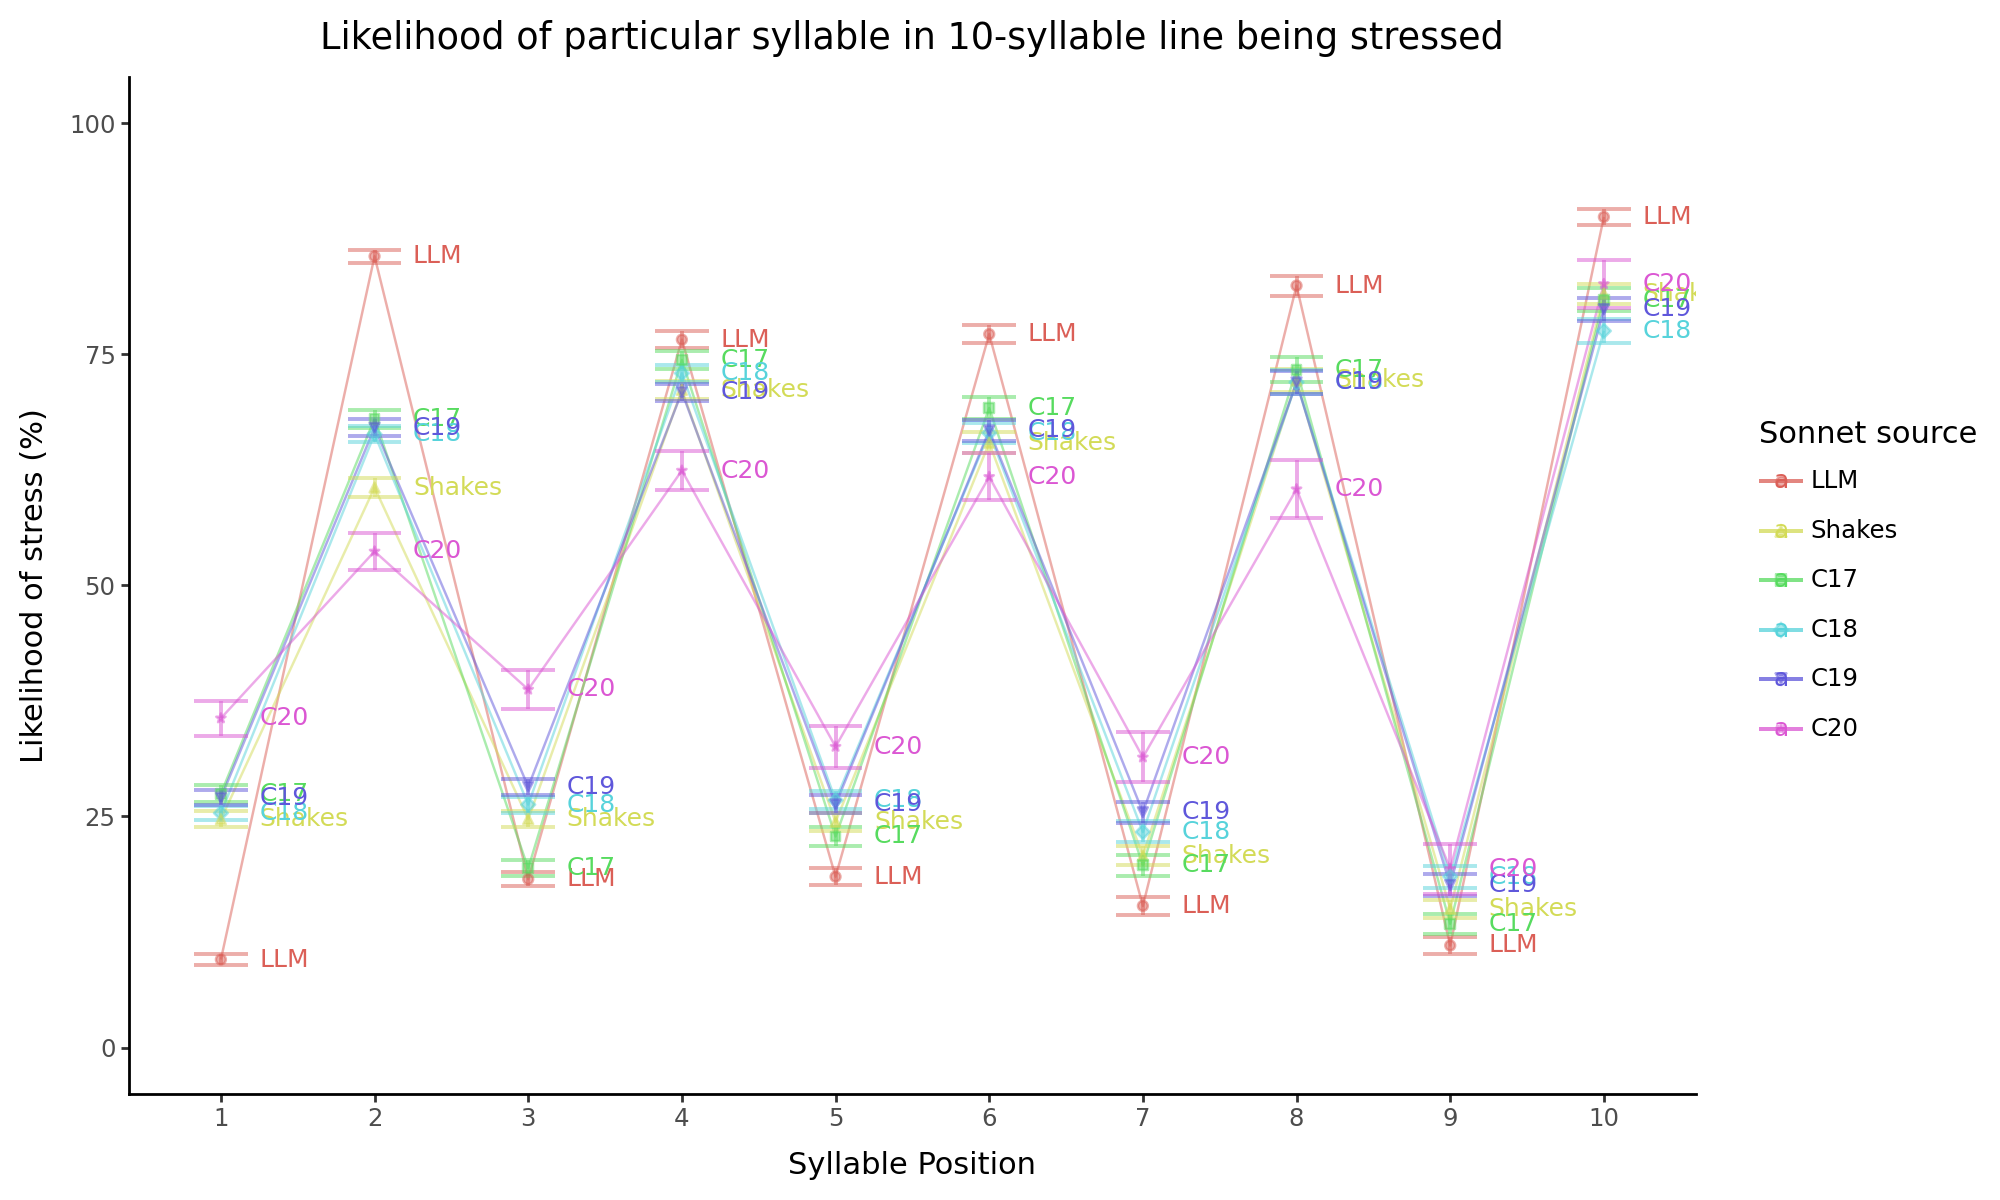

In [68]:
plot_figdf_flex(prom_type='stress')

In [14]:
from collections import Counter

def get_figdf_flex_poems(parses_df=None):
    if parses_df is None:
        parses_df = get_flex_parses_df()
    ld=[]
    for g,gdf in parses_df.groupby('stanza_num'):
        parse_meters = ''.join(gdf.parse_meter)
        parse_meters_4thpos = gdf.parse_meter.apply(lambda x: int(x[3]=='+'))
        parse_meter_count = Counter(find_pos_in_meter_str(parse_meters))
        
        d = {'stanza_num':g, 'mpos_ww':parse_meter_count['--'] / parse_meter_count.total(), 'parse_meter_4thpos':parse_meters_4thpos.mean()
             }
        ld.append(d)
    figdf = pd.DataFrame(ld).merge(parses_df.reset_index().drop_duplicates('stanza_num'), on='stanza_num', how='left')
    return figdf

figdf_flex_poems = get_figdf_flex_poems(flex_parses_df)
figdf_flex_poems.agent.value_counts()

agent
human-markov          154
C17-19                153
Shakes                153
shakespeare-markov    150
LLM                   147
C20                    38
Name: count, dtype: int64

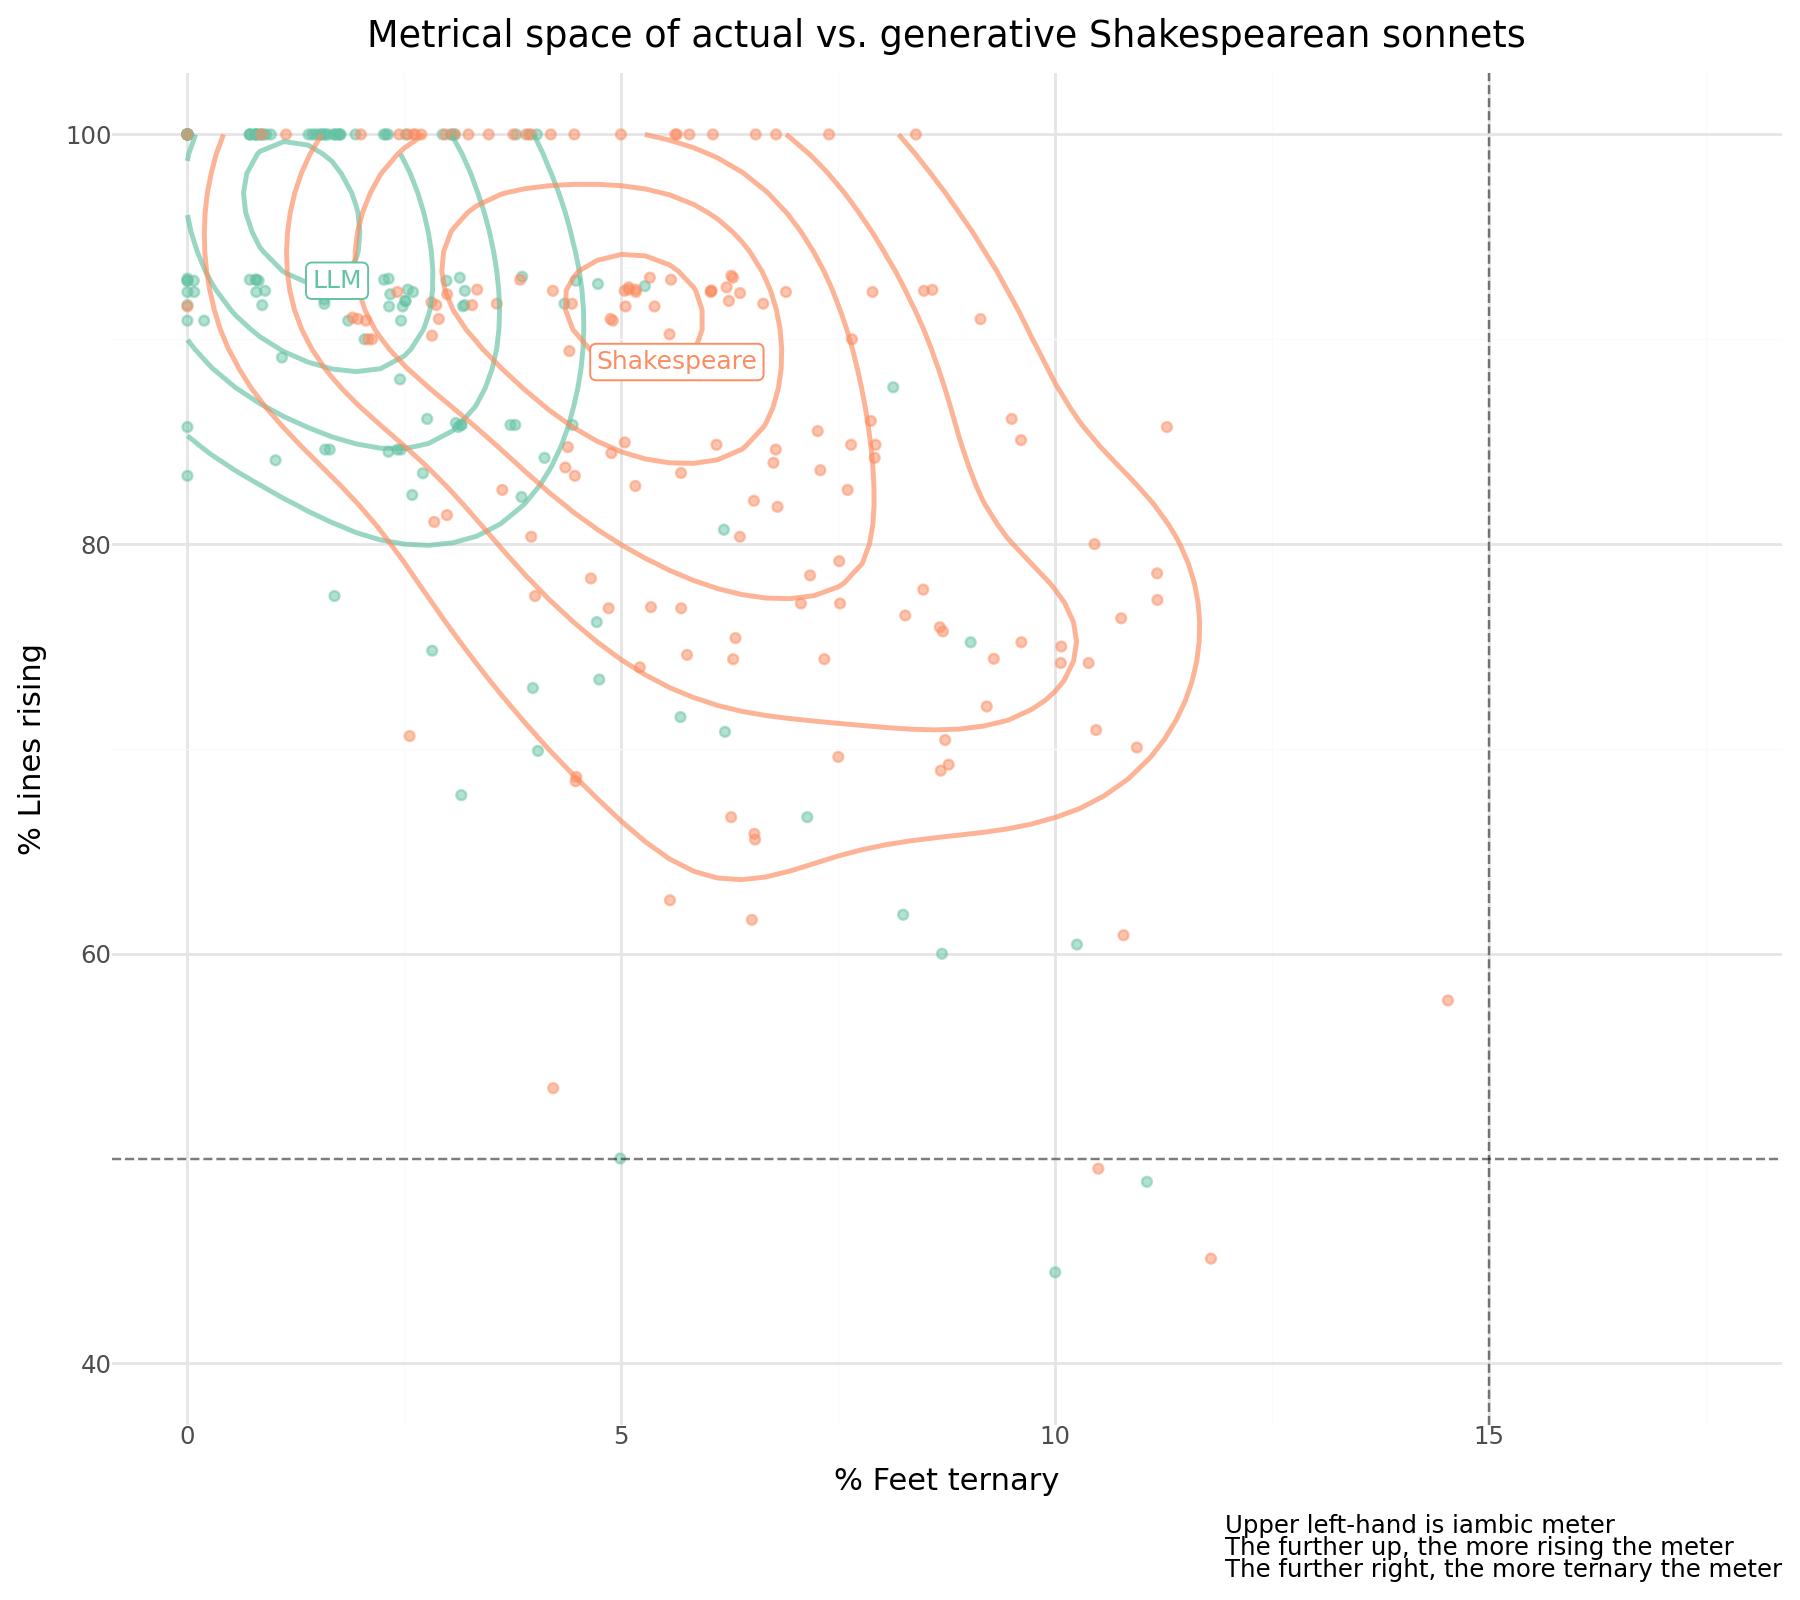

In [23]:
def plot_hood_space(figdf=None):
    if figdf is None:
        figdf = get_figdf_flex_poems().copy()

    # figdf = figdf.query('mpos_ww < .25')
    # figdf = figdf.query('parse_meter_4thpos > .25')
    # def get_agent_now(model):
    #     if model.startswith('b. '):
    #         return 'C17-C20'
    #         cents = int(model[3:5])+1
    #         if cents in {17,18}:
    #             return 'C17-18'
    #         return f'C{cents}'
    #     if model == 'shakespeare':
    #         return 'Shakespeare'
    #     else:
    #         return get_agent(model)
        


    # figdf['agent'] = figdf['model'].apply(get_agent_now)
    # figdf['agent'] = pd.Categorical(figdf['agent'], categories=['Shakespeare', 'C17-C20', 'Markov','LLM'], ordered=True)

    # def get_model_category(model,agent):
    #     model = str(model)
    #     agent = str(agent)
    #     if agent.startswith('Markov'):
    #         return 'Markov'
    #         if 'shakespeare' in model.lower():
    #             return 'Markov (Shakespeare)'
    #         else:
    #             return 'Markov (C17-20)'
    #     elif model.startswith('b.'):
    #         cents = int(model[3:5])+1
    #         if cents in {17,18,19}:
    #             return 'C17-19'
    #         return f'C{cents}'
    #     else:
    #         return agent

    # figdf['model_cat'] = figdf.apply(lambda row: get_model_category(row['model'],row['agent']), axis=1)
    # print(figdf['model_cat'].value_counts())
    # figdf['model_cat'] = pd.Categorical(figdf['model_cat'], categories=['Shakespeare', 'C17-19', 'C20', 'Markov', 'LLM'], ordered=True)

    figdf['agent'] = figdf['agent'].str.replace('Shakes','Shakespeare')
    figdf = figdf[~figdf['agent'].str.startswith('C')]
    # figdf = figdf.groupby('model_cat').head(154)
    figdf = figdf[~figdf.agent.isin({'human-markov'})]
    figdf['agent'] = figdf['agent'].str.replace('shakespeare-markov','Markov')
    figdf = figdf[~figdf['agent'].str.startswith('Markov')]
    figdf['mpos_ww']*=100
    figdf['parse_meter_4thpos']*=100

    p9.options.figure_size = (9, 8)
    title='Upper left-hand is iambic meter'
    title+='\nThe further up, the more rising the meter'
    title+='\nThe further right, the more ternary the meter'
    fig = (
        p9.ggplot(figdf, p9.aes(x="mpos_ww", y="parse_meter_4thpos", color='agent', label='agent'))
        + p9.geom_point(size=1.5, alpha=.5)
        + p9.geom_density_2d(size=1, alpha=.666)
        + p9.geom_label(size=9, data=figdf.groupby(['agent']).median(numeric_only=True).reset_index())
        # + p9.facet_wrap('agent',ncol=2)
        # + p9.facet_wrap('agent',nrow=1)
        + p9.theme_minimal()
        + p9.theme(legend_position='none')
        + p9.scale_color_brewer(type='qual', palette='Set2')
        + p9.scale_x_continuous(limits=(0,17.5))
        + p9.scale_y_continuous(limits=(40,100))
        + p9.labs(y='% Lines rising', x='% Feet ternary', caption=title, title='Metrical space of actual vs. generative Shakespearean sonnets')
        + p9.geom_vline(xintercept=15, linetype='dashed', alpha=0.5)
        + p9.geom_hline(yintercept=50, linetype='dashed', alpha=0.5)
    )
    fig.save('../../generative-humanities/Figures/HoodSpace2.png')
    return fig


# figdf=plot_hood_space(figdf_flex_poems)
# figdf[['agent','model','model_cat']]
plot_hood_space()

In [32]:
import plotnine as p9

def get_figdf_iambic_pentameter(parses_df):
    figdf = parses_df.reset_index()

    figdf['agent'] = figdf['model'].apply(get_agent)
    figdf = figdf[~figdf['agent'].isin({'Markov2'})]

    figdf = pd.concat(
        gdf.assign(meter_syll_num=gdf.sort_values(['meterpos_num', 'meterslot_num']).groupby(['meterpos_num','meterslot_num']).ngroup() + 1)
        for g,gdf in figdf.groupby(['stanza_num','line_num','parse_meter','parse_rank'])
    )
    figdf = figdf.query('meter_syll_num <= 10')

    def get_line_num_type(line_num):
        if line_num in [1,2,3,4]:
            return 'Q1'
        elif line_num in [5,6,7,8]:
            return 'Q2'
        elif line_num in [9,10,11,12]:
            return 'Q3'
        elif line_num in [13,14]:
            return 'CC'

    figdf['line_num_type'] = figdf['line_num'].apply(get_line_num_type)

    # Get violation columns (those starting with *)
    viol_cols = [col for col in figdf.columns if col.startswith('*')]

    # Melt the DataFrame
    figdf_melted = pd.melt(
        figdf,
        id_vars=['meter_syll_num','line_num','agent'],
        value_vars=viol_cols,
        var_name='violation_type',
        value_name='violation_value'
    )
    figdf_melted['violation_value']*=100
    # Clean up violation_type names by removing the *
    figdf_melted['violation_type'] = figdf_melted['violation_type'].str.replace('*', '')

    p9.options.figure_size = (8, 6)
    figdf_melted['label'] = figdf_melted['violation_value'].apply(lambda x: f'{int(round(x*100))}%')

    violnames = {
        's_unstress': '*Lapse (Missing stress in strong position)',
        'w_stress': '*Clash (Unexpected stress in weak position)',
        'w_peak': '*Peak (Unexpected polysyllabic stress in weak position)',
        # 'unres_across': '*Unresolved across',
        # 'unres_within': '*Unresolved within',
    }

    figdf_melted['violation_type'] = figdf_melted['violation_type'].apply(lambda x: violnames.get(x, x))
    figdf_melted['meter_syll_num'] = pd.Categorical(figdf_melted['meter_syll_num'].astype(int))

    figdf_melted = figdf_melted[figdf_melted.violation_type.isin(set(violnames.values()))]
    figdf_melted['violation_type'] = pd.Categorical(figdf_melted['violation_type'], categories=list(violnames.values()))
    figdf_melted.agent.value_counts()

    return figdf_melted

figdf_melted = get_figdf_iambic_pentameter(flex_parses_df)

In [ ]:

import numpy as np
# Calculate mean and standard error for the line plot
line_data = (figdf_melted
             .groupby(['meter_syll_num','violation_type','agent'])
             .agg({
                 'violation_value': ['mean', 'std', 'count']
             })
             .reset_index())
line_data.columns = ['meter_syll_num', 'violation_type', 'agent', 'mean', 'std', 'count']
line_data['violation_value'] = line_data['mean']
line_data['se'] = line_data['std'] / np.sqrt(line_data['count'])
def safe_add(a, b):
    try:
        return a + b
    except TypeError:
        return float('nan')

def safe_subtract(a, b):
    try:
        return a - b
    except TypeError:
        return float('nan')

line_data['upper'] = line_data.apply(lambda row: safe_add(row['mean'], row['se']), axis=1)
line_data['lower'] = line_data.apply(lambda row: safe_subtract(row['mean'], row['se']), axis=1)
line_data['group'] = line_data['agent'].astype(str)# + '_' + line_data['violation_type'].astype(str)
line_data = line_data.query('mean>0')
line_data = line_data.sort_values(['group','meter_syll_num'])
line_data

In [ ]:
figdf_now = figdf_melted#.query('label != "0%"')
# line_data['line_count'] = line_data['count'] / 14


p9.options.figure_size = (10, 10)

fig = (p9.ggplot(figdf_now, 
                 p9.aes(x='meter_syll_num', 
                        y='violation_value',
                        color='agent')) + 
       p9.geom_line(p9.aes(group='agent'), size=.5, data=line_data, alpha=.5) +
 
       p9.geom_errorbar(p9.aes(ymin='lower', ymax='upper'), data=line_data, width=.35, size=.8, alpha=.5) +
       p9.geom_text(p9.aes(label='agent'),size=8, data=line_data.query('mean>0'), position=p9.position_nudge(x=.25)) +
       p9.geom_point(p9.aes(shape='agent'), data=line_data, alpha=.5) +
       p9.scale_size_continuous(range=[1,3]) +
       p9.theme_classic() +
#        p9.facet_grid('violation_type~agent', scales='free_y') +
#        p9.facet_wrap('agent', scales='free_y') +
       p9.facet_wrap('violation_type', ncol=1, scales='free_y') +
       p9.scale_color_brewer(type='qual', palette='Set1') +
       p9.labs(x='Syllable Position', 
               y='Violation Rate',
               fill='Violation Type',
               title='Metrical rule violations to iambic pentameter by syllable'
               ))
fig = fig + p9.theme(legend_position='bottom')
fig.save('../../generative-humanities/Figures/ViolsBySyll.png')
fig